In [3]:
# Diagnostics: check ensemble artifacts before SHAP runs
import os, json, datetime as dt
from pathlib import Path
ART_DIR = Path('../results/hybrid_b')
required = [
    'feature_names.json',
    'stack_test_X.npy',
    'lookback.json',
    'test_dates.npy',
    'xgb_t1.json',
    'xgb_t3.json',
    'xgb_t5.json',
]
missing = [f for f in required if not (ART_DIR / f).exists()]
if missing:
    print('Missing artifacts:', missing)
    print('Run the pipeline cell in notebooks/05_ensemble_methods.ipynb first.')
else:
    ts = max((ART_DIR / f).stat().st_mtime for f in required)
    print('Artifacts present. Last updated:', dt.datetime.fromtimestamp(ts))


Artifacts present. Last updated: 2025-12-12 18:02:28.874776


## 1. Environment Setup and Data Loading
- Load required SHAP + visualization libraries
- Import processed dataset for context (dates, masks)
- Load saved Hybrid Model B artifacts for explainability

In [4]:
# Load artifacts from pipeline (skip retraining in this notebook)

from pathlib import Path
import json
import yaml
import sys

# Ensure project root available for src imports
PROJECT_ROOT = Path.cwd().parents[0]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

# Import pipeline helpers
from src.explainability.shap_analyzer import load_artifacts, compute_shap

# Config and results directory
CONFIG_PATH = Path("configs/hybrid_b.yaml")
RESULTS_DIR = Path("results/hybrid_b")

# Ensure artifacts exist; if not, instruct to run ensemble notebook
if not (RESULTS_DIR / "feature_names.json").exists():
    raise FileNotFoundError("Artifacts not found. Please run the ensemble notebook to generate models and features.")

# Load artifacts
xgb_models_B, stack_test_X, feature_names, lookback_info = load_artifacts(RESULTS_DIR)
lookback = lookback_info

# Set horizons for consistency
horizons = ['t1', 't3', 't5']

# Compute SHAP using loaded models and test features
shap_values_dict, explainers_dict = compute_shap(xgb_models_B, stack_test_X)

print("Artifacts loaded and SHAP values computed from saved models.")

c:\Users\reset\OneDrive - UWE Bristol\Master_project\UK-inflation-forecasting-XAI\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


FileNotFoundError: Artifacts not found. Please run the ensemble notebook to generate models and features.

In [ ]:
# Environment setup and lightweight library imports
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

plt.style.use("seaborn-v0_8")
sns.set(font_scale=1.05)

print("Libraries loaded successfully")
print(f"SHAP version: {shap.__version__}")

Libraries loaded successfully
SHAP version: 0.50.0
LIME library imported successfully


In [ ]:
# Load dataset once (for dates/context only)
from datetime import datetime

def find_project_root(marker: str = "data") -> Path:
    cwd = Path.cwd()
    for path in (cwd, *cwd.parents):
        if (path / marker).exists():
            return path
    raise FileNotFoundError(f"Could not find project root containing '{marker}' directory")

PROJECT_ROOT = find_project_root()
DATA_PATH = PROJECT_ROOT / "notebooks" / "model_ready_dataset.csv"

df = pd.read_csv(DATA_PATH)
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

train_end = pd.Timestamp('2017-12-31')
val_end = pd.Timestamp('2021-12-31')
train_mask = df['date'] <= train_end
val_mask = (df['date'] > train_end) & (df['date'] <= val_end)
test_mask = df['date'] > val_end

test_dates = df.loc[test_mask, 'date'].values[lookback:]
print(f"Data shape: {df.shape}")
print(f"Train/Val/Test sizes: {train_mask.sum()} / {val_mask.sum()} / {test_mask.sum()}")
print(f"SHAP test window spans {test_dates[0].date()} to {test_dates[-1].date()}")

Data loaded: (327, 18)
Train: 241, Val: 48, Test: 38


## 2. Artifact Sanity Check
- Confirm saved Hybrid B boosters + stacked features load correctly
- Validate SHAP arrays are available for each forecast horizon
- Keep everything aligned to the previously trained ensemble

## 3. SHAP Analysis: Global Feature Importance
- Use TreeExplainer for XGBoost models (exact, fast)
- Compute SHAP values for test set
- Visualize global feature importance per horizon
- Generate summary plots (beeswarm) showing feature impacts

In [ ]:
# Sanity check SHAP arrays loaded from artifacts
for h in horizons:
    shap_vals = shap_values_dict[h]
    print(f"{h.upper()} horizon SHAP shape: {shap_vals.shape}")
print("All SHAP tensors ready for visualization.")


Computing SHAP values for t1...
SHAP values shape for t1: (20, 17)

Computing SHAP values for t3...
SHAP values shape for t3: (20, 17)

Computing SHAP values for t5...
SHAP values shape for t5: (20, 17)

SHAP computation complete for all horizons


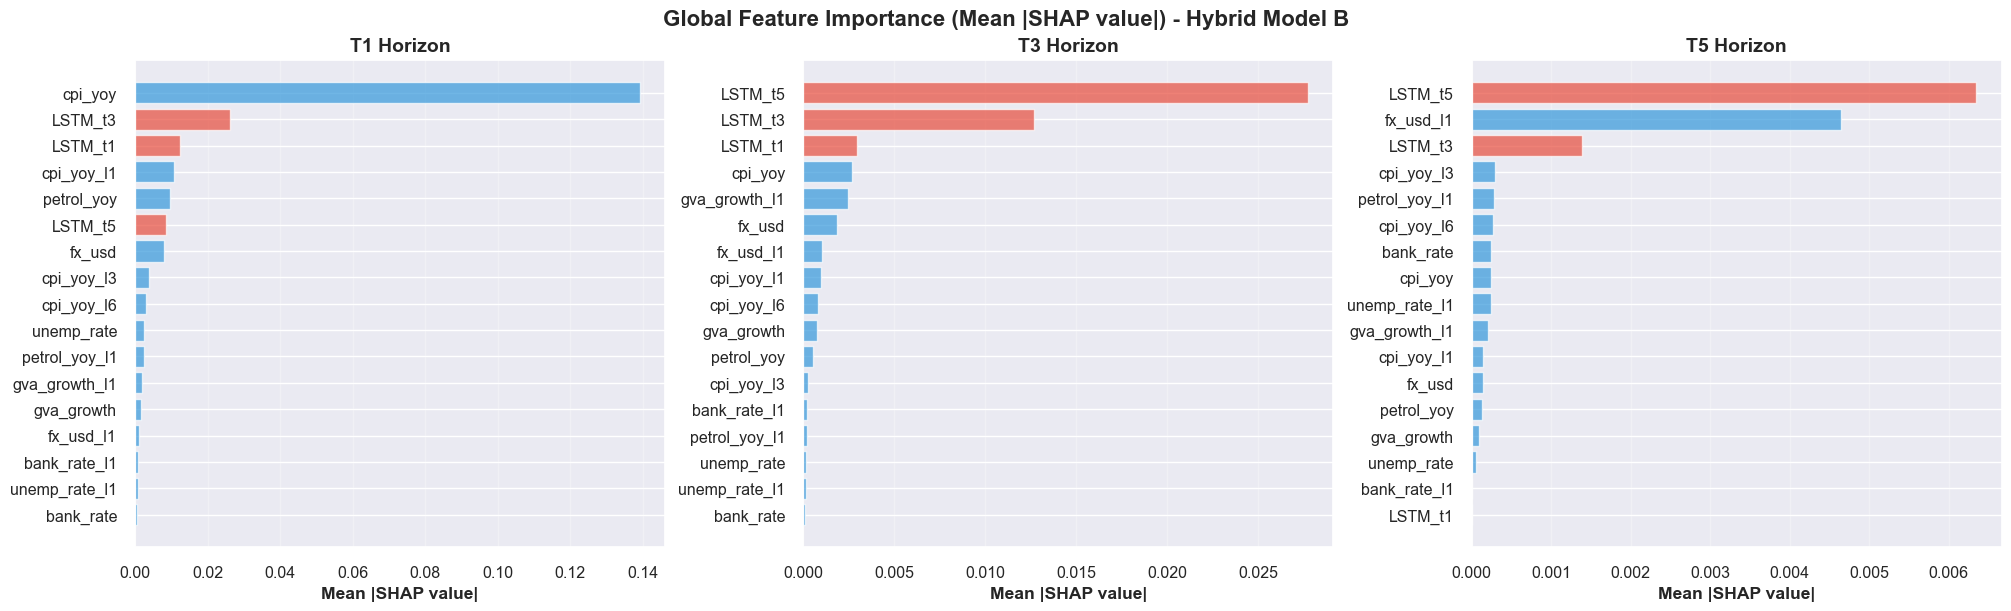


Top 5 Features by Horizon (Mean |SHAP value|)

T1:
  cpi_yoy              0.1392
  LSTM_t3              0.0261
  LSTM_t1              0.0123
  cpi_yoy_l1           0.0106
  petrol_yoy           0.0095

T3:
  LSTM_t5              0.0277
  LSTM_t3              0.0127
  LSTM_t1              0.0029
  cpi_yoy              0.0027
  gva_growth_l1        0.0025

T5:
  LSTM_t5              0.0063
  fx_usd_l1            0.0046
  LSTM_t3              0.0014
  cpi_yoy_l3           0.0003
  petrol_yoy_l1        0.0003


In [ ]:
# Global feature importance: Mean absolute SHAP values

fig, axes = plt.subplots(1, 3, figsize=(20, 6), constrained_layout=True)
fig.suptitle('Global Feature Importance (Mean |SHAP value|) - Hybrid Model B', 
             fontsize=16, fontweight='bold')

for idx, (h, ax) in enumerate(zip(horizons, axes)):
    shap_vals = shap_values_dict[h]
    
    # Calculate mean absolute SHAP values
    mean_abs_shap = np.abs(shap_vals).mean(axis=0)
    
    # Create feature importance dataframe
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': mean_abs_shap
    }).sort_values('Importance', ascending=True)
    
    # Plot horizontal bar chart
    colors = ['#e74c3c' if 'LSTM' in f else '#3498db' for f in importance_df['Feature']]
    ax.barh(importance_df['Feature'], importance_df['Importance'], color=colors, alpha=0.7)
    
    ax.set_xlabel('Mean |SHAP value|', fontweight='bold')
    ax.set_title(f'{h.upper()} Horizon', fontweight='bold', fontsize=14)
    ax.grid(alpha=0.3, axis='x')
    
plt.show()

# Print top 5 features per horizon
print("\n" + "="*80)
print("Top 5 Features by Horizon (Mean |SHAP value|)")
print("="*80)
for h in horizons:
    shap_vals = shap_values_dict[h]
    mean_abs_shap = np.abs(shap_vals).mean(axis=0)
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': mean_abs_shap
    }).sort_values('Importance', ascending=False)
    
    print(f"\n{h.upper()}:")
    for i, row in importance_df.head(5).iterrows():
        print(f"  {row['Feature']:<20} {row['Importance']:.4f}")


SHAP Summary Plot: T1 Horizon


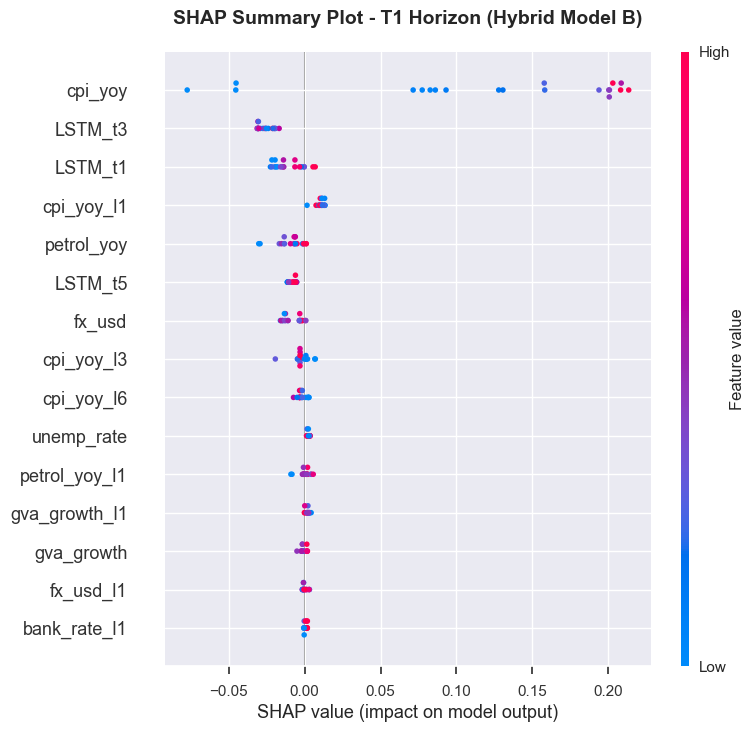


SHAP Summary Plot: T3 Horizon


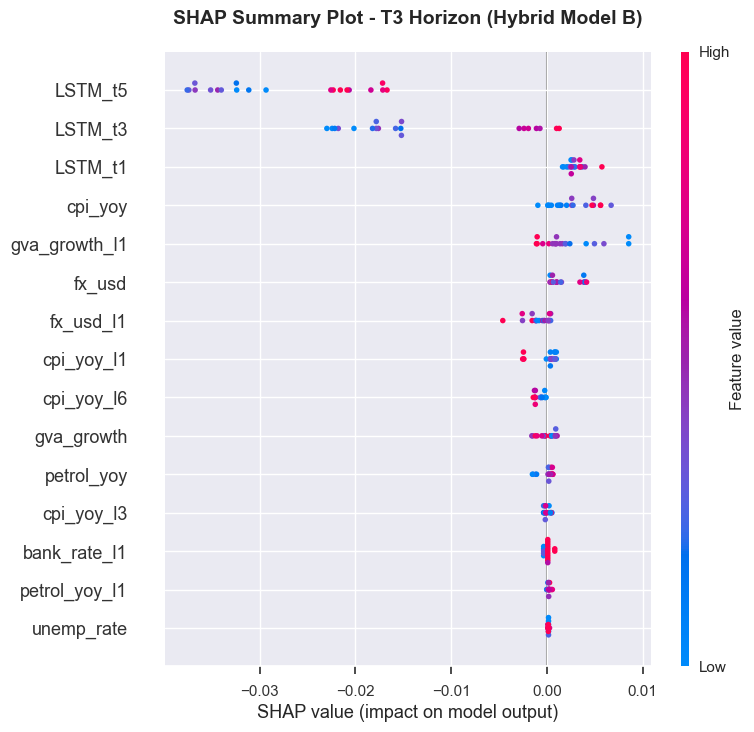


SHAP Summary Plot: T5 Horizon


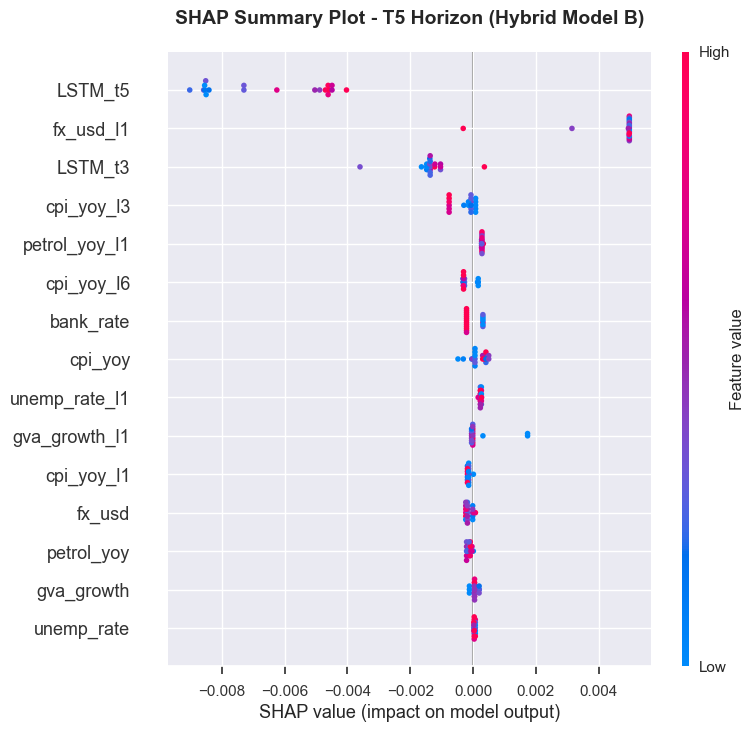

In [ ]:
# SHAP Summary Plots (Beeswarm) - shows feature value impact on predictions

for h in horizons:
    print(f"\n{'='*80}")
    print(f"SHAP Summary Plot: {h.upper()} Horizon")
    print(f"{'='*80}")
    
    plt.figure(figsize=(12, 8))
    shap.summary_plot(
        shap_values_dict[h], 
        stack_test_X, 
        feature_names=feature_names,
        show=False,
        max_display=15
    )
    plt.title(f'SHAP Summary Plot - {h.upper()} Horizon (Hybrid Model B)', 
             fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()

## 4. SHAP Analysis: Local Explanations
- Waterfall plots for individual predictions
- Force plots showing contribution breakdown
- Select representative samples from test set
- Interpret how features drive specific forecasts

In [ ]:
# Select representative samples for local explanations

# Get actual test dates for context
test_dates = df[test_mask]['date'].values[lookback:]

# Select samples: early, middle, late in test period
sample_indices = [0, len(stack_test_X)//2, len(stack_test_X)-1]
sample_labels = ['Early Test (2022)', 'Mid Test (2023)', 'Late Test (2024)']

print("Selected samples for local explanation:")
for idx, label in zip(sample_indices, sample_labels):
    date = test_dates[idx]
    print(f"  Sample {idx}: {label} - {date}")

Selected samples for local explanation:
  Sample 0: Early Test (2022) - 2023-07-01T00:00:00.000000000
  Sample 10: Mid Test (2023) - 2024-05-01T00:00:00.000000000
  Sample 19: Late Test (2024) - 2025-02-01T00:00:00.000000000



SHAP Waterfall Plots: T1 Horizon


Early Test (2022):


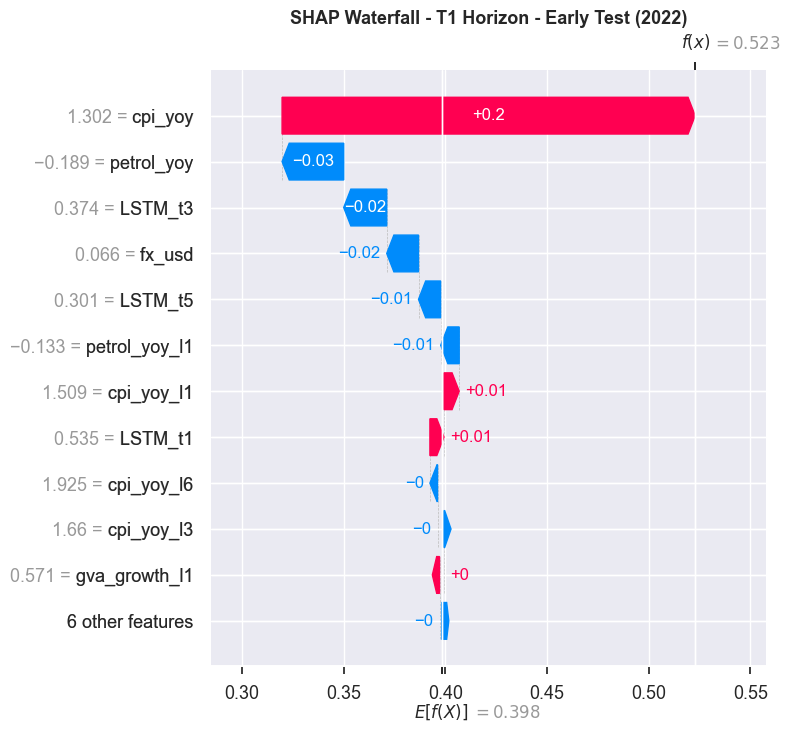


Mid Test (2023):


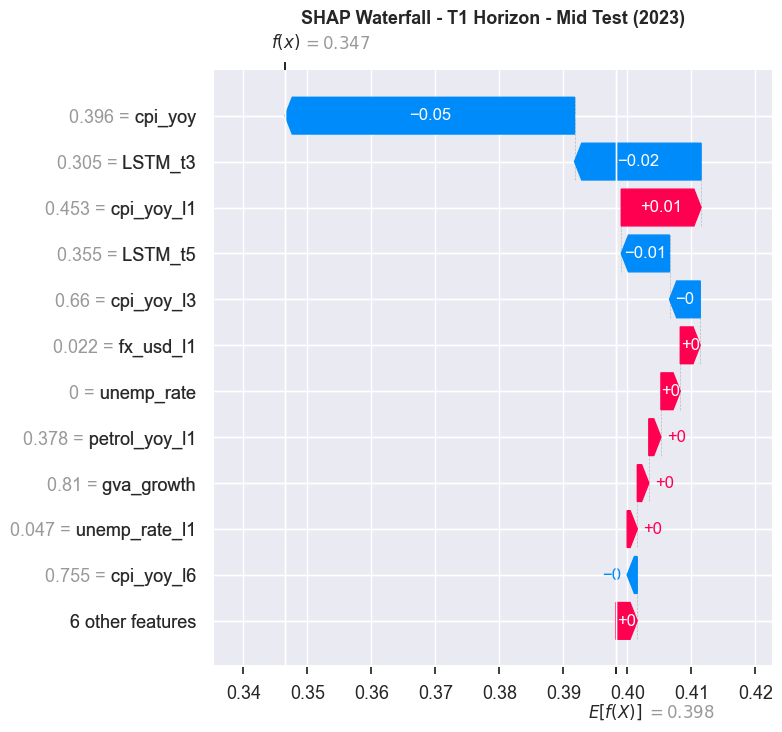


Late Test (2024):


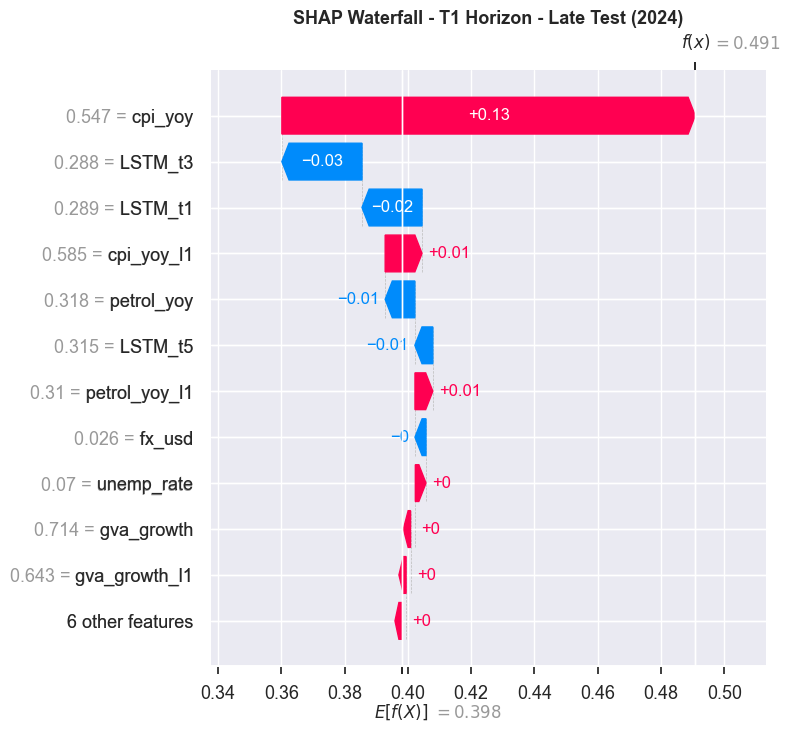


SHAP Waterfall Plots: T3 Horizon


Early Test (2022):


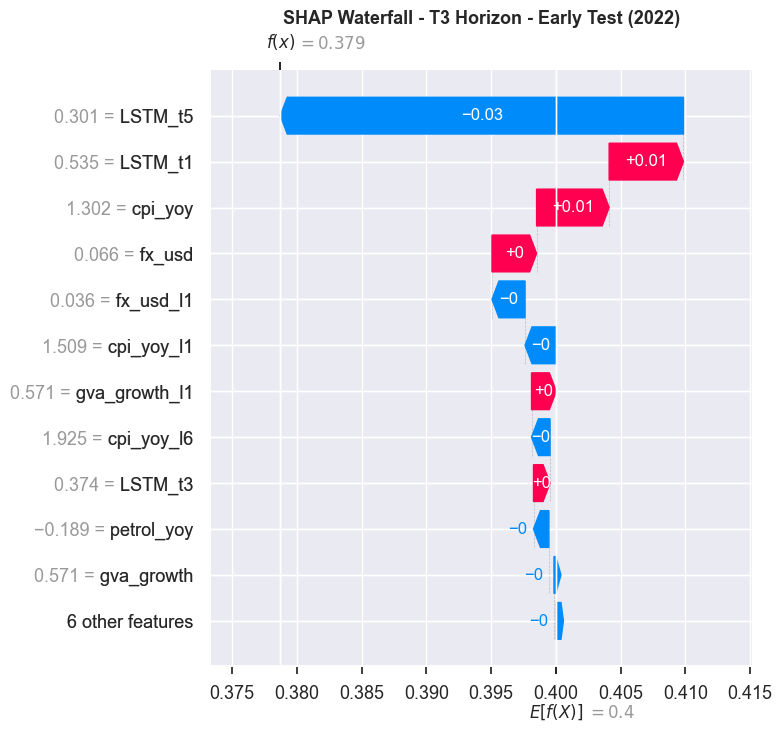


Mid Test (2023):


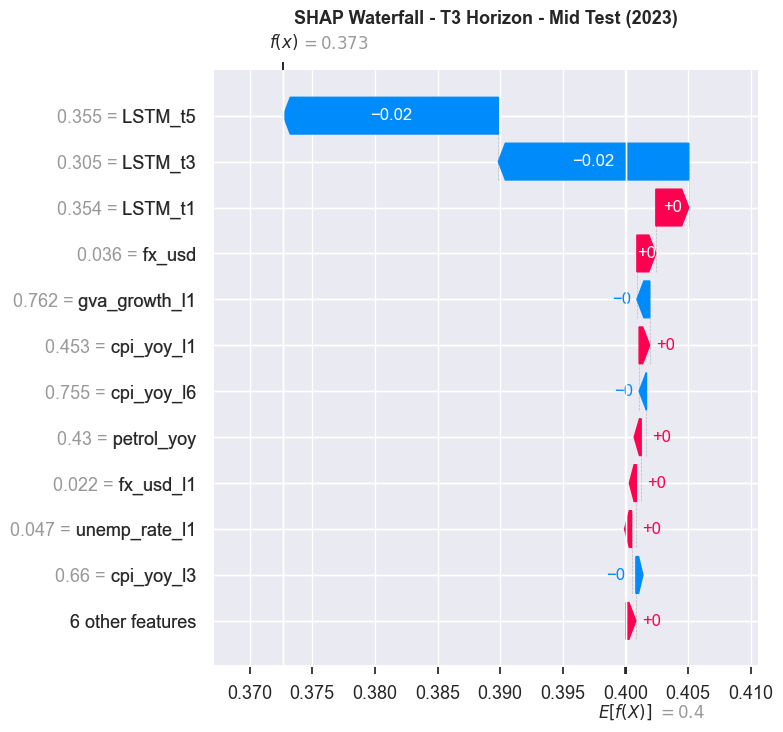


Late Test (2024):


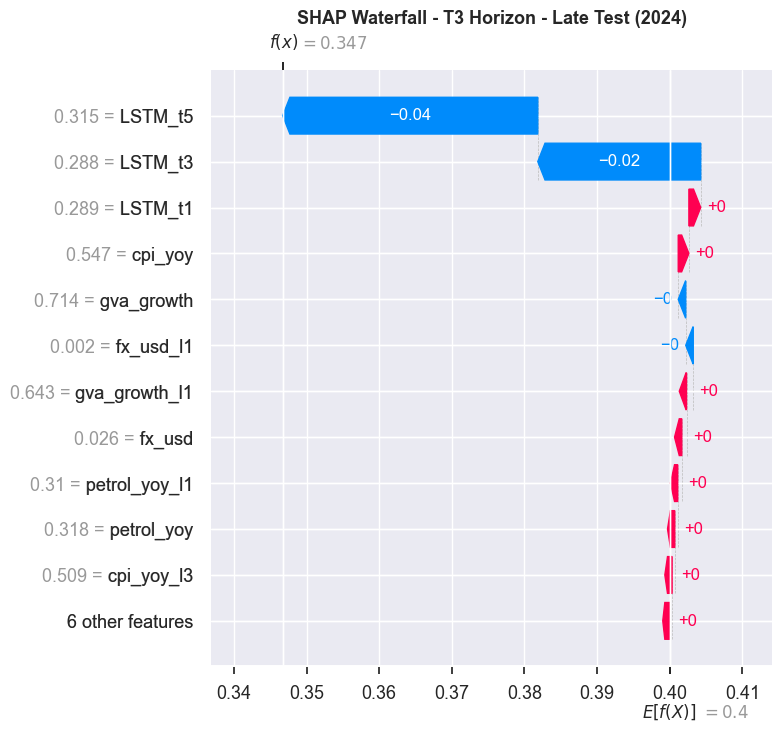


SHAP Waterfall Plots: T5 Horizon


Early Test (2022):


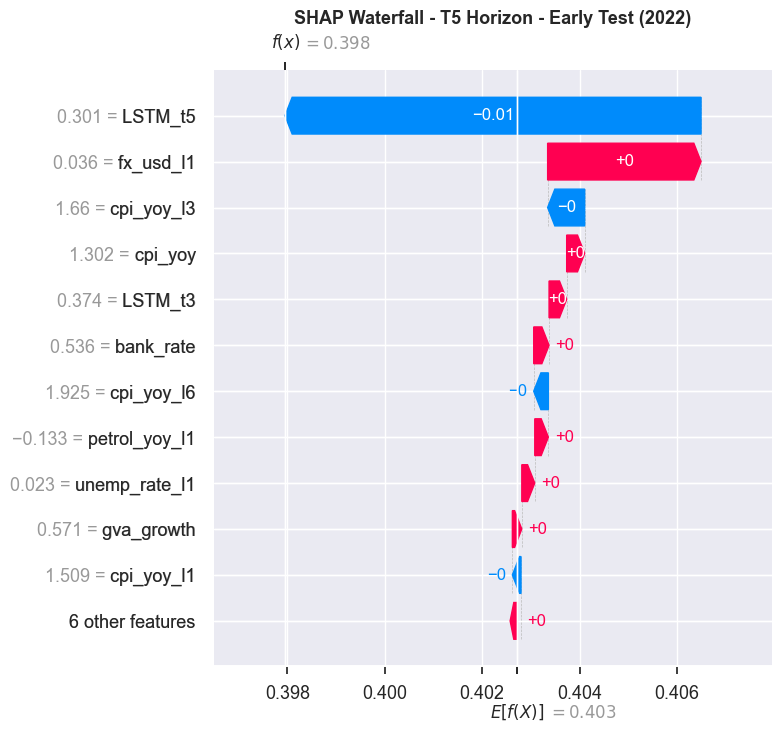


Mid Test (2023):


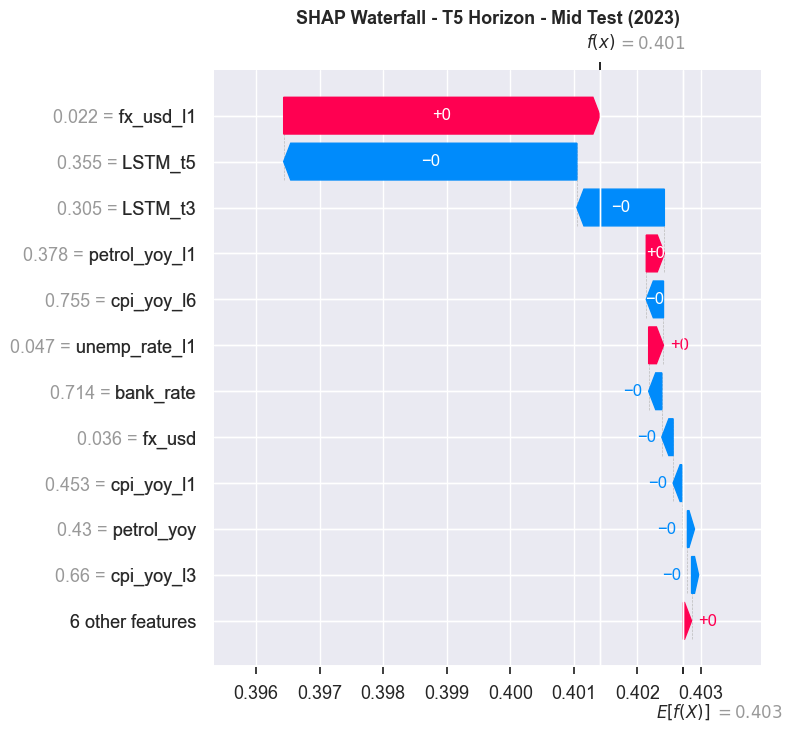


Late Test (2024):


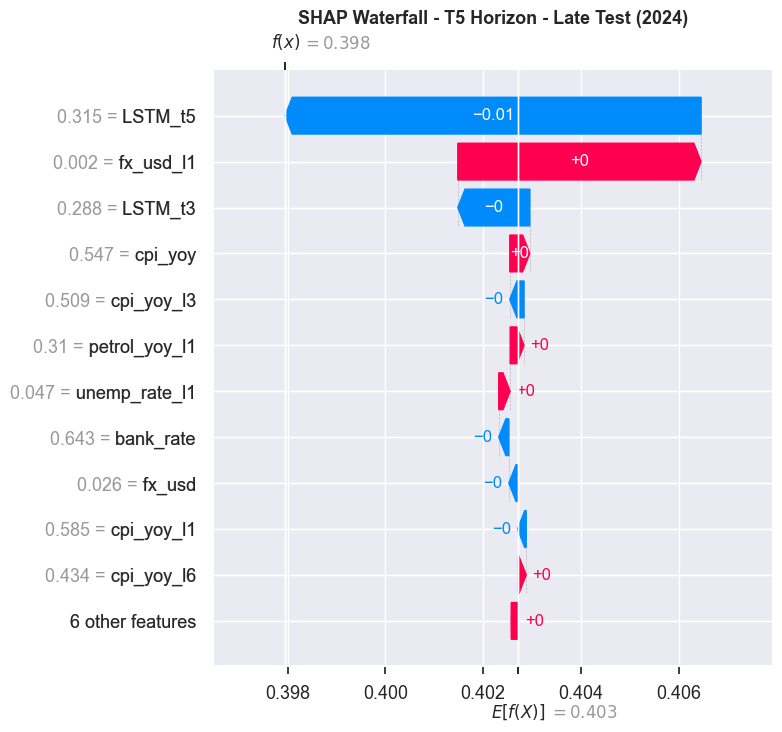

In [ ]:
# SHAP Waterfall plots for individual predictions

for h in horizons:
    print(f"\n{'='*80}")
    print(f"SHAP Waterfall Plots: {h.upper()} Horizon")
    print(f"{'='*80}\n")
    
    for sample_idx, sample_label in zip(sample_indices, sample_labels):
        
        # Create SHAP Explanation object
        explanation = shap.Explanation(
            values=shap_values_dict[h][sample_idx],
            base_values=explainers_dict[h].expected_value,
            data=stack_test_X[sample_idx],
            feature_names=feature_names
        )
        
        # Waterfall plot
        print(f"\n{sample_label}:")
        plt.figure(figsize=(12, 6))
        shap.waterfall_plot(explanation, max_display=12, show=False)
        plt.title(f'SHAP Waterfall - {h.upper()} Horizon - {sample_label}',
                 fontsize=13, fontweight='bold')
        plt.tight_layout()
        plt.show()

## 4. Summary & Interpretation

**Key Questions Addressed:**
- Which engineered + LSTM features drive Hybrid B across horizons?
- How do contributions shift over the test window (2022–2024)?
- What are the macro takeaways from SHAP-global and SHAP-local views?

In [ ]:
# Global feature importance summary across horizons

print("\n" + "="*80)
print("GLOBAL FEATURE IMPORTANCE SUMMARY")
print("="*80 + "\n")

for h in horizons:
    print(f"\n{h.upper()} Horizon:")
    print("-" * 40)
    
    # Calculate mean absolute SHAP values
    mean_abs_shap = np.mean(np.abs(shap_values_dict[h]), axis=0)
    
    # Sort features
    sorted_idx = np.argsort(mean_abs_shap)[::-1]
    
    print("\nTop 10 Most Important Features (SHAP):")
    for i, idx in enumerate(sorted_idx[:10], 1):
        print(f"  {i:2d}. {feature_names[idx]:30s} | Mean |SHAP|: {mean_abs_shap[idx]:.4f}")


GLOBAL FEATURE IMPORTANCE SUMMARY


T1 Horizon:
----------------------------------------

Top 10 Most Important Features (SHAP):
   1. cpi_yoy                        | Mean |SHAP|: 0.1392
   2. LSTM_t3                        | Mean |SHAP|: 0.0261
   3. LSTM_t1                        | Mean |SHAP|: 0.0123
   4. cpi_yoy_l1                     | Mean |SHAP|: 0.0106
   5. petrol_yoy                     | Mean |SHAP|: 0.0095
   6. LSTM_t5                        | Mean |SHAP|: 0.0084
   7. fx_usd                         | Mean |SHAP|: 0.0079
   8. cpi_yoy_l3                     | Mean |SHAP|: 0.0038
   9. cpi_yoy_l6                     | Mean |SHAP|: 0.0029
  10. unemp_rate                     | Mean |SHAP|: 0.0026

T3 Horizon:
----------------------------------------

Top 10 Most Important Features (SHAP):
   1. LSTM_t5                        | Mean |SHAP|: 0.0277
   2. LSTM_t3                        | Mean |SHAP|: 0.0127
   3. LSTM_t1                        | Mean |SHAP|: 0.0029
   4. cpi

### Economic Interpretation

**Analysis Framework:**
- Examine how LSTM-derived features compare to traditional economic indicators
- Identify relationships between feature contributions and economic conditions
- Assess temporal patterns in feature importance across test samples

**Key Questions:**
1. Do LSTM predictions dominate explanations, or do tabular features remain influential?
2. Which economic indicators show strongest predictive power for different horizons?
3. How does feature importance shift across different economic periods (2022-2024)?

In [ ]:
# Feature category analysis

# Define feature categories
lstm_features = [f for f in feature_names if 'lstm_pred' in f.lower()]
tabular_features = [f for f in feature_names if 'lstm_pred' not in f.lower()]

print("\n" + "="*80)
print("FEATURE CATEGORY IMPORTANCE")
print("="*80 + "\n")

for h in horizons:
    print(f"\n{h.upper()} Horizon:")
    print("-" * 40)
    
    # Get mean absolute SHAP values
    mean_abs_shap = np.mean(np.abs(shap_values_dict[h]), axis=0)
    
    # Separate by category
    lstm_idx = [i for i, f in enumerate(feature_names) if f in lstm_features]
    tabular_idx = [i for i, f in enumerate(feature_names) if f in tabular_features]
    
    lstm_importance = mean_abs_shap[lstm_idx].sum()
    tabular_importance = mean_abs_shap[tabular_idx].sum()
    total_importance = lstm_importance + tabular_importance
    
    print(f"\n  LSTM Features Contribution:     {lstm_importance:.4f} ({100*lstm_importance/total_importance:.1f}%)")
    print(f"  Tabular Features Contribution:  {tabular_importance:.4f} ({100*tabular_importance/total_importance:.1f}%)")
    
    # Top tabular features
    tabular_mean_abs = mean_abs_shap[tabular_idx]
    tabular_sorted = np.argsort(tabular_mean_abs)[::-1]
    
    print(f"\n  Top 5 Tabular Features:")
    for i, idx in enumerate(tabular_sorted[:5], 1):
        feat_name = tabular_features[idx]
        importance = tabular_mean_abs[idx]
        print(f"    {i}. {feat_name:30s} | {importance:.4f}")


FEATURE CATEGORY IMPORTANCE


T1 Horizon:
----------------------------------------

  LSTM Features Contribution:     0.0000 (0.0%)
  Tabular Features Contribution:  0.2327 (100.0%)

  Top 5 Tabular Features:
    1. cpi_yoy                        | 0.1392
    2. LSTM_t3                        | 0.0261
    3. LSTM_t1                        | 0.0123
    4. cpi_yoy_l1                     | 0.0106
    5. petrol_yoy                     | 0.0095

T3 Horizon:
----------------------------------------

  LSTM Features Contribution:     0.0000 (0.0%)
  Tabular Features Contribution:  0.0555 (100.0%)

  Top 5 Tabular Features:
    1. LSTM_t5                        | 0.0277
    2. LSTM_t3                        | 0.0127
    3. LSTM_t1                        | 0.0029
    4. cpi_yoy                        | 0.0027
    5. gva_growth_l1                  | 0.0025

T5 Horizon:
----------------------------------------

  LSTM Features Contribution:     0.0000 (0.0%)
  Tabular Features Contribution:  0.0

### Conclusions

**SHAP Analysis Complete**

This streamlined notebook now focuses on the most decision-critical explainability deliverables:
1. Global feature importance (bar + beeswarm) for each horizon.
2. Local waterfall explanations for representative dates across the test set.
3. Feature-category split (LSTM predictions vs core economic indicators) to quantify where signal originates.

Use these insights to guide the discussion, refine feature engineering, or contrast Hybrid B with other ensembles.